# Aula Prática: Do Zero ao Primeiro Modelo Preditivo (com Dados Reais)

**Pós-graduação PUC Minas | Machine Learning | Encontro 2**

Nesta aula prática vamos sair da teoria e colocar a mão em dados de verdade. Vamos usar o **California Housing**, um conjunto de dados real e amplamente usado no ensino de Machine Learning, com o preço de imóveis de diversos bairros da Califórnia, coletado no censo de 1990.

Usamos o California Housing em vez do tradicional Boston Housing porque o Boston Housing foi removido das principais bibliotecas de Machine Learning: ele contém uma variável construída com um viés racial problemático. O California Housing é igualmente real, simples e didático, sem esse problema.

Vamos passar por todos os algoritmos vistos na Unidade 2, cobrindo as fases que qualquer projeto de Machine Learning precisa:

1. **Regressão Linear Simples**: vamos carregar os dados reais, dar os primeiros passos de preparação e treinar o modelo mais simples que existe em Machine Learning, usando apenas uma variável.
2. **Árvore de Decisão nos Dados Já Preparados**: vamos reaproveitar os mesmos dados, já limpos por nós na Etapa 1, e treinar um segundo modelo usando todas as variáveis numéricas de uma vez.
3. **Regularização (Ridge e Lasso)**: as duas variações da Regressão Linear que ajudam a evitar overfitting.
4. **Random Forest (Bagging)**: muitas árvores treinadas em paralelo, votando juntas.
5. **XGBoost (Boosting)**: muitas árvores treinadas em sequência, cada uma corrigindo o erro da anterior.

No fim, vamos comparar todos os modelos e discutir quando usar cada um.

Nenhum código aqui é complicado. Se algo não fizer sentido, essa é a hora de perguntar.

**Antes de começar**: baixe o arquivo `housing.csv` e deixe-o na mesma pasta deste notebook.

## 0. Preparando o Ambiente

Antes de qualquer coisa, importamos as bibliotecas que vamos usar durante toda a aula:

- `pandas`: para organizar os dados em tabelas.
- `numpy`: para contas numéricas.
- `matplotlib`: para os gráficos.
- `sklearn` (scikit-learn): a biblioteca de Machine Learning que vamos usar para treinar os modelos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from xgboost import XGBRegressor

# Deixa os gráficos com um tamanho legível
plt.rcParams['figure.figsize'] = (7, 5)

# Aqui vamos guardar as métricas de cada modelo, para comparar todos no final da aula
resultados = {}

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


---

## Etapa 1: Regressão Linear Simples com Dados Reais

A ideia da Regressão Linear é encontrar a reta que melhor representa a relação entre duas variáveis:

$$\hat{y} = w \cdot x + b$$

Onde:
- $x$ é a variável que usamos para prever (o que sabemos)
- $\hat{y}$ é o preço previsto (o que queremos descobrir)
- $w$ e $b$ são os números que o modelo vai aprender sozinho

Antes de treinar qualquer modelo, porém, precisamos passar pelas fases de sempre: carregar os dados, entender as colunas, e arrumar o que estiver faltando.

### 1.1 Carregando os Dados Reais

Vamos carregar o arquivo `housing.csv`. Cada linha representa um bairro (quarteirão censitário) da Califórnia.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

# Substitua o caminho abaixo pela pasta exata onde o arquivo está no seu Google Drive
# Exemplo: '/content/drive/MyDrive/Seu_Diretorio/custo_medico.csv'
caminho_arquivo = '/content/drive/MyDrive/AulaPUC/2026/Machine Learning LLM/Pratica02/housing_boston.csv'
dados = pd.read_csv(caminho_arquivo)
dados.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [9]:
dados["ocean_proximity"]

,ocean_proximity
0,NEAR BAY
1,NEAR BAY
2,NEAR BAY
3,NEAR BAY
4,NEAR BAY
...,...
20635,INLAND
20636,INLAND
20637,INLAND
20638,INLAND


In [ ]:
#dados = pd.read_csv('housing.csv')

#print(f'Formato dos dados: {dados.shape[0]} linhas, {dados.shape[1]} colunas')
#dados.head()

### 1.2 Conhecendo as Colunas

- `longitude`, `latitude`: localização geográfica do bairro
- `housing_median_age`: idade média dos imóveis do bairro
- `total_rooms`: total de cômodos no bairro
- `total_bedrooms`: total de quartos no bairro
- `population`: população do bairro
- `households`: número de domicílios do bairro
- `median_income`: renda média das famílias do bairro (em dezenas de milhares de dólares; por exemplo, `3.5` significa US$ 35.000)
- `ocean_proximity`: uma categoria em texto, indicando a distância do bairro até o oceano
- `median_house_value`: **o valor médio dos imóveis do bairro, em dólares** (é o que vamos prever)

### 1.3 Um Primeiro Olhar nos Dados

Antes de treinar qualquer modelo, sempre vale a pena olhar as estatísticas básicas de cada coluna, e também checar se falta alguma informação.

In [10]:
dados.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [11]:
dados.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


In [12]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Reparem na coluna `total_bedrooms`: ela tem menos valores preenchidos (`non-null`) do que as outras. Isso significa que existem linhas com informação faltando, algo extremamente comum em dados reais.

### 1.4 Lidando com Dados Faltantes

Existem várias formas de lidar com valores faltando (por exemplo, preencher com a média da coluna). Para manter esta primeira aula simples, vamos usar a abordagem mais direta: remover as linhas que têm alguma informação faltando.

In [13]:
print(f'Linhas antes da limpeza: {len(dados)}')

dados_limpos = dados.dropna()

print(f'Linhas depois da limpeza: {len(dados_limpos)}')

Linhas antes da limpeza: 20640
Linhas depois da limpeza: 20433


In [15]:
dados_limpos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


### 1.5 Escolhendo Uma Única Variável

Para a nossa primeira Regressão Linear, vamos manter as coisas simples e usar apenas **uma** variável de entrada: `median_income`, a renda média do bairro. Faz sentido imaginar que bairros mais ricos tendem a ter imóveis mais caros, e é isso que vamos verificar.

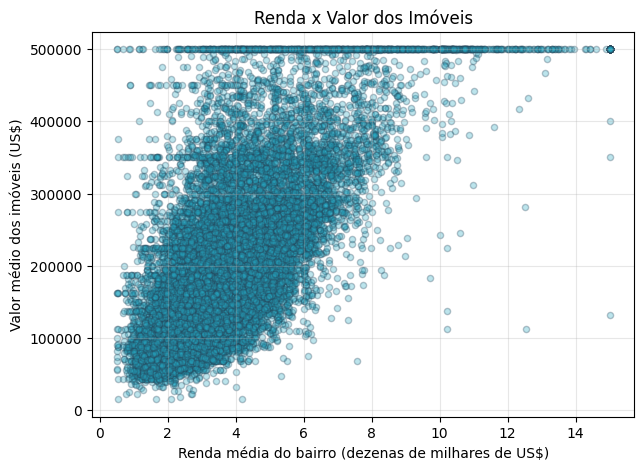

In [16]:
plt.scatter(dados_limpos['median_income'], dados_limpos['median_house_value'],
            color='#23A8C3', edgecolor='#244357', alpha=0.3, s=20)
plt.xlabel('Renda média do bairro (dezenas de milhares de US$)')
plt.ylabel('Valor médio dos imóveis (US$)')
plt.title('Renda x Valor dos Imóveis')
plt.grid(alpha=0.3)
plt.show()

Percebam a tendência: quanto maior a renda média do bairro, maior o valor dos imóveis. A nuvem de pontos é mais espalhada do que no nosso exemplo artificial de outras aulas, e é exatamente assim que dados reais costumam se comportar.

Vale notar também uma "linha reta" de pontos no topo do gráfico, perto de US\$ 500.000: isso é uma limitação do próprio dataset original, que arredondou todos os valores acima desse teto para exatamente esse número. É outro exemplo de "sujeira" que aparece em dados reais.

### 1.6 Separando Treino e Teste

Um princípio fundamental em Machine Learning: **nunca avaliamos o modelo com os mesmos dados usados para treiná-lo**. Por isso, separamos uma parte dos dados para treino e guardamos uma parte para teste, sem o modelo ver.

In [17]:
X = dados_limpos[['median_income']]
y = dados_limpos['median_house_value']

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Exemplos de treino: {len(X_treino)}')
print(f'Exemplos de teste: {len(X_teste)}')

Exemplos de treino: 16346
Exemplos de teste: 4087


### 1.7 Treinando o Modelo

Com o scikit-learn, treinar o modelo são duas linhas de código.

In [18]:
# 1. Criamos o modelo (ainda "vazio", sem ter aprendido nada)
modelo_linear = LinearRegression()

# 2. Treinamos o modelo com os dados de treino: ele vai encontrar o melhor w e o melhor b
modelo_linear.fit(X_treino, y_treino)

print('Modelo treinado!')

Modelo treinado!


### 1.8 Olhando o Que o Modelo Aprendeu

Lembram da fórmula $\hat{y} = w \cdot x + b$? Vamos ver os valores de $w$ e $b$ que o modelo encontrou sozinho.

In [19]:
w = modelo_linear.coef_[0]
b = modelo_linear.intercept_

print(f'w (inclinação da reta) = {w:.2f}')
print(f'b (ponto onde a reta cruza o eixo y) = {b:.2f}')
print()
print(f'Isso significa: valor_previsto = {w:.2f} * renda_media + {b:.2f}')

w (inclinação da reta) = 41751.96
b (ponto onde a reta cruza o eixo y) = 45035.23

Isso significa: valor_previsto = 41751.96 * renda_media + 45035.23


### 1.9 Fazendo Previsões e Visualizando a Reta

Vamos usar o modelo treinado para prever os valores do conjunto de teste, e desenhar a reta aprendida por cima dos dados reais.

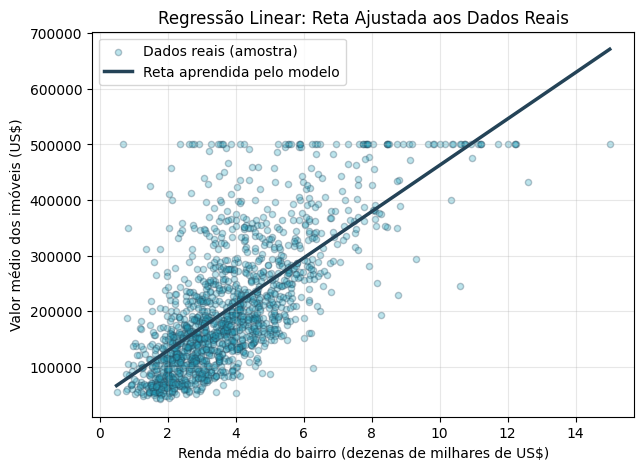

In [20]:
y_previsto = modelo_linear.predict(X_teste)

# Gera pontos ao longo de todo o eixo x para desenhar a reta completa
x_linha = pd.DataFrame({'median_income': np.linspace(X['median_income'].min(), X['median_income'].max(), 100)})
y_linha = modelo_linear.predict(x_linha)

# Usamos uma amostra dos pontos para o gráfico não ficar poluído
amostra = dados_limpos.sample(1500, random_state=42)

plt.scatter(amostra['median_income'], amostra['median_house_value'],
            color='#23A8C3', edgecolor='#244357', alpha=0.3, s=20, label='Dados reais (amostra)')
plt.plot(x_linha, y_linha, color='#244357', linewidth=2.5, label='Reta aprendida pelo modelo')
plt.xlabel('Renda média do bairro (dezenas de milhares de US$)')
plt.ylabel('Valor médio dos imóveis (US$)')
plt.title('Regressão Linear: Reta Ajustada aos Dados Reais')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 1.10 Avaliando o Modelo

Uma reta no gráfico ajuda a entender visualmente, mas para comparar modelos de verdade precisamos de números. Vamos calcular as principais métricas de erro para regressão, as mesmas que vimos na aula teórica:

- **MAE** (Erro Absoluto Médio): o erro médio, em dólares, sem se importar se o modelo errou para cima ou para baixo.
- **MSE** (Erro Quadrático Médio): parecido com o MAE, mas penaliza mais os erros grandes.
- **RMSE**: a raiz quadrada do MSE, na mesma unidade do preço (dólares), o que facilita a interpretação.
- **R²**: o quanto o modelo explica da variação dos preços, de 0 (nada) a 1 (perfeito).
- **MAPE**: o erro médio em porcentagem, fácil de explicar para quem não é técnico.

In [21]:
mae = mean_absolute_error(y_teste, y_previsto)
mse = mean_squared_error(y_teste, y_previsto)
rmse = np.sqrt(mse)
r2 = r2_score(y_teste, y_previsto)
mape = mean_absolute_percentage_error(y_teste, y_previsto)

print(f'MAE  = US$ {mae:,.2f}')
print(f'MSE  = {mse:,.2f}')
print(f'RMSE = US$ {rmse:,.2f}')
print(f'R2   = {r2:.2f}')
print(f'MAPE = {mape:.2%}')

resultados['Regressão Linear (1 variável)'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

MAE  = US$ 63,374.55
MSE  = 7,221,011,204.24
RMSE = US$ 84,976.53
R2   = 0.47
MAPE = 38.78%


Um R² bem abaixo de 1 é esperado aqui: estamos prevendo o valor de um imóvel usando **apenas a renda média** do bairro. Faz sentido que outras informações, como localização e idade dos imóveis, também influenciem o preço. É exatamente isso que vamos explorar na Etapa 2.

### Sua Vez

Complete o código abaixo para prever o valor médio de imóveis em um bairro com renda média de `5.0` (ou seja, US\$ 50.000). Dica: use `modelo_linear.predict(...)`, passando uma tabela com uma única linha e uma única coluna, chamada `median_income`.

In [22]:
# TODO: complete a linha abaixo
renda_nova = pd.DataFrame({'median_income': [5.0]})
valor_previsto = modelo_linear.predict(renda_nova)

print(f'Valor médio previsto para renda de US$ 50.000: US$ {valor_previsto[0]:,.2f}')

Valor médio previsto para renda de US$ 50.000: US$ 253,795.02


---

## Etapa 2: Um Segundo Modelo nos Dados Já Preparados

Na Etapa 1, fizemos o trabalho de carregar os dados reais e removê-los das linhas incompletas (`dados_limpos`). Essa é exatamente a base "já preparada" que, em um projeto de verdade, você entregaria para o próximo passo de modelagem.

Vamos reaproveitar esses mesmos dados, mas desta vez treinar uma **Árvore de Decisão**, o modelo que vimos na aula teórica como bloco fundamental de Random Forest e XGBoost, e usar **todas** as colunas numéricas de uma vez, não apenas a renda.

### 2.1 Selecionando as Features

A coluna `ocean_proximity` é texto, não número, então vamos deixá-la de fora por enquanto (fica de exercício para casa). Todas as outras colunas, menos o alvo `median_house_value`, entram como features.

In [ ]:
colunas_numericas = dados_limpos.drop(columns=['median_house_value', 'ocean_proximity'])

X_completo = colunas_numericas
y_completo = dados_limpos['median_house_value']

print('Features usadas:', list(X_completo.columns))

### 2.2 Separando Treino e Teste

Mesmo processo de sempre: uma parte para o modelo aprender, outra para testarmos de forma justa.

In [ ]:
X_treino_c, X_teste_c, y_treino_c, y_teste_c = train_test_split(X_completo, y_completo, test_size=0.2, random_state=42)

print(f'Exemplos de treino: {len(X_treino_c)}')
print(f'Exemplos de teste: {len(X_teste_c)}')

### 2.3 Treinando a Árvore de Decisão

O código para treinar continua igual em espírito ao da Regressão Linear: criar o modelo e chamar `.fit(...)`.

Vamos limitar a profundidade da árvore (`max_depth=8`). Lembram da aula teórica? Uma árvore muito profunda decora os dados de treino (overfitting) e depois erra mais no teste.

In [ ]:
modelo_arvore = DecisionTreeRegressor(max_depth=8, random_state=42)
modelo_arvore.fit(X_treino_c, y_treino_c)

print('Modelo treinado!')

### 2.4 Avaliando o Modelo

Vamos calcular as mesmas métricas da Etapa 1, para conseguirmos comparar os dois modelos de forma justa.

In [ ]:
y_previsto_c = modelo_arvore.predict(X_teste_c)

mae_c = mean_absolute_error(y_teste_c, y_previsto_c)
rmse_c = np.sqrt(mean_squared_error(y_teste_c, y_previsto_c))
r2_c = r2_score(y_teste_c, y_previsto_c)
mape_c = mean_absolute_percentage_error(y_teste_c, y_previsto_c)

print(f'MAE  = US$ {mae_c:,.2f}')
print(f'RMSE = US$ {rmse_c:,.2f}')
print(f'R2   = {r2_c:.2f}')
print(f'MAPE = {mape_c:.2%}')

resultados['Árvore de Decisão'] = {'MAE': mae_c, 'RMSE': rmse_c, 'R2': r2_c}

Comparem o R² deste modelo com o da Etapa 1. Usar mais informação (localização, idade dos imóveis, população) e um modelo que capta relações não lineares deve melhorar bastante a previsão.

### 2.5 Quais Features Mais Importam?

Uma vantagem prática das árvores de decisão: elas nos dizem quais colunas mais ajudaram a explicar o preço. Isso é muito útil para conversar com quem não é técnico sobre o que está guiando as previsões do modelo.

In [ ]:
importancias = pd.Series(modelo_arvore.feature_importances_, index=X_completo.columns)
importancias = importancias.sort_values(ascending=True)

plt.barh(importancias.index, importancias.values, color='#23A8C3', edgecolor='#244357')
plt.xlabel('Importância')
plt.title('Quais Features Mais Influenciam o Valor do Imóvel?')
plt.grid(alpha=0.3, axis='x')
plt.show()

Não é surpresa a renda aparecer entre as mais importantes, como já vimos na Etapa 1, mas reparem como a localização (`latitude` e `longitude`) também pesa bastante: faz sentido, já que "localização" é o mantra clássico do mercado imobiliário.

### 2.6 Visualizando a Árvore

Uma das grandes vantagens da Árvore de Decisão sobre outros modelos: dá para desenhar exatamente o que ela aprendeu, pergunta por pergunta. O scikit-learn tem uma função pronta para isso, a `plot_tree`.

O `modelo_arvore` que treinamos tem `max_depth=8`, profundo demais para caber legível numa tela. Então, só para visualizar, vamos treinar uma segunda árvore bem mais rasa (`max_depth=3`), nos mesmos dados. Ela é menos precisa, mas serve para enxergarmos a lógica de perguntas e respostas por trás do modelo.

In [ ]:
from sklearn.tree import plot_tree

modelo_arvore_viz = DecisionTreeRegressor(max_depth=3, random_state=42)
modelo_arvore_viz.fit(X_treino_c, y_treino_c)

plt.figure(figsize=(20, 8))
plot_tree(modelo_arvore_viz, feature_names=X_completo.columns, filled=True, rounded=True, fontsize=9)
plt.show()

Cada retângulo é um nó: mostra a pergunta feita (ex.: `median_income <= 5.0`), quantos exemplos de treino chegaram até ali (`samples`) e o valor médio previsto para eles (`value`). Seguindo os ramos da esquerda (resposta "sim" para a pergunta) até a direita (resposta "não"), chegamos numa folha, exatamente como vimos na aula teórica.

Reparem que a primeira pergunta, no topo da árvore, é sobre `median_income`: é a variável que a árvore considerou mais importante para começar a separar os imóveis, o mesmo resultado que vimos no gráfico de importância de features acima.

---

## Etapa 3: Regularização (Ridge e Lasso)

Na aula teórica vimos que a Regressão Linear pode sofrer overfitting quando tem muitas variáveis, algumas delas pouco úteis ou parecidas entre si. Ridge e Lasso são duas variações da Regressão Linear que resolvem isso adicionando uma **penalidade** ao tamanho dos coeficientes ($w$): coeficientes muito grandes passam a "custar caro" para o modelo, então ele só os aumenta quando realmente vale a pena.

- **Ridge**: encolhe os coeficientes em direção a zero, mas raramente os zera de vez.
- **Lasso**: pode zerar completamente o coeficiente de uma feature, funcionando também como uma seleção automática de variáveis.

Vamos usar os mesmos dados multivariados da Etapa 2 (`X_completo`, `y_completo`).

### 3.1 Padronizando as Features

Ridge e Lasso penalizam o tamanho dos coeficientes, então as colunas precisam estar na mesma escala: caso contrário, uma coluna como `population` (com valores na casa dos milhares) seria penalizada de forma muito diferente de `housing_median_age` (com valores na casa das dezenas). O `StandardScaler` transforma cada coluna para ter média 0 e desvio padrão 1.

In [ ]:
scaler = StandardScaler()

X_treino_pad = scaler.fit_transform(X_treino_c)
X_teste_pad = scaler.transform(X_teste_c)

print('Features padronizadas!')

### 3.2 Treinando o Ridge

O parâmetro `alpha` controla a força da penalidade: quanto maior o `alpha`, mais o modelo encolhe os coeficientes. Começamos com um valor comum, `alpha=1.0`.

In [ ]:
modelo_ridge = Ridge(alpha=1.0)
modelo_ridge.fit(X_treino_pad, y_treino_c)

y_previsto_ridge = modelo_ridge.predict(X_teste_pad)

mae_ridge = mean_absolute_error(y_teste_c, y_previsto_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_teste_c, y_previsto_ridge))
r2_ridge = r2_score(y_teste_c, y_previsto_ridge)

print(f'MAE  = US$ {mae_ridge:,.2f}')
print(f'RMSE = US$ {rmse_ridge:,.2f}')
print(f'R2   = {r2_ridge:.2f}')

resultados['Ridge'] = {'MAE': mae_ridge, 'RMSE': rmse_ridge, 'R2': r2_ridge}

### 3.3 Treinando o Lasso

O mesmo código, trocando só o modelo. Vamos usar um `alpha` menor, já que o Lasso costuma precisar de uma penalidade mais suave para não zerar features demais.

In [ ]:
modelo_lasso = Lasso(alpha=0.1)
modelo_lasso.fit(X_treino_pad, y_treino_c)

y_previsto_lasso = modelo_lasso.predict(X_teste_pad)

mae_lasso = mean_absolute_error(y_teste_c, y_previsto_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_teste_c, y_previsto_lasso))
r2_lasso = r2_score(y_teste_c, y_previsto_lasso)

print(f'MAE  = US$ {mae_lasso:,.2f}')
print(f'RMSE = US$ {rmse_lasso:,.2f}')
print(f'R2   = {r2_lasso:.2f}')

resultados['Lasso'] = {'MAE': mae_lasso, 'RMSE': rmse_lasso, 'R2': r2_lasso}

### 3.4 O Que o Lasso Zerou?

Vamos ver os coeficientes que o Lasso aprendeu para cada feature. Se algum ficar em `0.00`, significa que o modelo decidiu que aquela coluna não ajuda a prever o preço.

In [ ]:
coef_lasso = pd.Series(modelo_lasso.coef_, index=X_completo.columns).sort_values()
coef_lasso

---

## Etapa 4: Random Forest (Bagging)

Lembram da "sabedoria das multidões"? Uma única árvore de decisão é instável e tem viés próprio. O Random Forest treina **muitas** árvores em paralelo, cada uma vendo uma amostra ligeiramente diferente dos dados (Bagging), e depois faz a média das previsões de todas elas.

O parâmetro `n_estimators` define quantas árvores treinar, e `max_depth` limita a profundidade de cada uma, exatamente como na Etapa 2.

In [ ]:
modelo_forest = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42)
modelo_forest.fit(X_treino_c, y_treino_c)

y_previsto_forest = modelo_forest.predict(X_teste_c)

mae_forest = mean_absolute_error(y_teste_c, y_previsto_forest)
rmse_forest = np.sqrt(mean_squared_error(y_teste_c, y_previsto_forest))
r2_forest = r2_score(y_teste_c, y_previsto_forest)

print(f'MAE  = US$ {mae_forest:,.2f}')
print(f'RMSE = US$ {rmse_forest:,.2f}')
print(f'R2   = {r2_forest:.2f}')

resultados['Random Forest'] = {'MAE': mae_forest, 'RMSE': rmse_forest, 'R2': r2_forest}

Reparem: o código para treinar é praticamente idêntico ao da árvore única na Etapa 2. A principal diferença é o `n_estimators`, que diz ao modelo quantas árvores treinar por baixo dos panos.

---

## Etapa 5: XGBoost (Boosting)

O XGBoost segue outra estratégia: treina árvores em **sequência**, e cada nova árvore foca em corrigir os erros que as árvores anteriores ainda estão cometendo (Boosting).

Três parâmetros para conhecer:

- `n_estimators`: quantas árvores treinar em sequência.
- `max_depth`: profundidade de cada árvore (geralmente bem menor do que no Random Forest, já que são muitas árvores simples se corrigindo).
- `learning_rate`: o quanto cada nova árvore pode corrigir o erro de uma vez. Valores menores tornam o aprendizado mais lento, porém mais estável.

In [ ]:
modelo_xgb = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.1, random_state=42)
modelo_xgb.fit(X_treino_c, y_treino_c)

y_previsto_xgb = modelo_xgb.predict(X_teste_c)

mae_xgb = mean_absolute_error(y_teste_c, y_previsto_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_teste_c, y_previsto_xgb))
r2_xgb = r2_score(y_teste_c, y_previsto_xgb)

print(f'MAE  = US$ {mae_xgb:,.2f}')
print(f'RMSE = US$ {rmse_xgb:,.2f}')
print(f'R2   = {r2_xgb:.2f}')

resultados['XGBoost'] = {'MAE': mae_xgb, 'RMSE': rmse_xgb, 'R2': r2_xgb}

---

## Fechando a Aula: Comparando Todos os Modelos

Treinamos seis modelos ao todo. Vamos juntar as métricas de cada um, guardadas em `resultados` ao longo da aula, em uma única tabela.

In [ ]:
tabela_resultados = pd.DataFrame(resultados).T.sort_values('R2', ascending=False)
tabela_resultados

In [ ]:
cores = ['#244357' if r2 == tabela_resultados['R2'].max() else '#23A8C3' for r2 in tabela_resultados['R2']]

plt.barh(tabela_resultados.index, tabela_resultados['R2'], color=cores, edgecolor='#244357')
plt.xlabel('R² (quanto maior, melhor)')
plt.title('Comparando o R² de Todos os Modelos')
plt.grid(alpha=0.3, axis='x')
plt.gca().invert_yaxis()
plt.show()

### O Que Aprendemos, Modelo por Modelo

| Modelo | Ideia Central | Vantagem | Cuidado |
|---|---|---|---|
| Regressão Linear | Uma reta ($\hat{y} = w \cdot x + b$) | Simples de treinar e de explicar | Só funciona bem se a relação for aproximadamente linear |
| Árvore de Decisão | Perguntas SE...ENTÃO em sequência | Captura relações não lineares, dá importância de features | Profunda demais decora os dados (overfitting) |
| Ridge | Regressão Linear com penalidade nos coeficientes | Reduz overfitting sem descartar features | Não elimina variáveis inúteis, só encolhe todas |
| Lasso | Regressão Linear com penalidade que pode zerar coeficientes | Também funciona como seleção de features | Pode zerar uma feature relevante se o `alpha` for alto demais |
| Random Forest | Muitas árvores em paralelo, tirando a média (Bagging) | Reduz a instabilidade de uma árvore única | Mais lento para treinar; menos fácil de interpretar do que uma árvore só |
| XGBoost | Muitas árvores em sequência, cada uma corrigindo a anterior (Boosting) | Costuma dar a maior precisão | Mais parâmetros para ajustar; maior risco de overfitting sem cuidado |

Passamos pelas fases que qualquer projeto de Machine Learning exige: carregar os dados, entender as colunas, lidar com valores faltando, separar treino e teste, treinar, prever e avaliar, e comparar modelos de forma justa usando as mesmas métricas.

### Para Praticar em Casa

1. Na Etapa 1, troque `median_income` por `housing_median_age` como variável de entrada. O modelo fica melhor ou pior? Por quê?
2. Na Etapa 2, teste `max_depth=3` e `max_depth=20` e compare o R² no treino e no teste. O que acontece com uma árvore muito rasa? E com uma muito profunda?
3. Na Etapa 3, teste `alpha=10` e `alpha=0.01` no Ridge e no Lasso. O que acontece com os coeficientes em cada caso?
4. Na Etapa 5, aumente `learning_rate` para `0.3` e reduza `n_estimators` para `50`. O resultado muda muito?
5. Desafio: use `pd.get_dummies(dados_limpos['ocean_proximity'])` para transformar a coluna de texto `ocean_proximity` em colunas numéricas, junte com as outras features, e treine o XGBoost de novo. As métricas melhoram?